RF data shape: (128, 2048)  →  128 beams × 2048 samples

Clustering RF data …
  Building features for 16384 RF points …
  Running DBSCAN (eps=0.35, min_samples=20) …
  Found 1 clusters, 2040 noise points (12.5%)

Building pixel↔RF map …


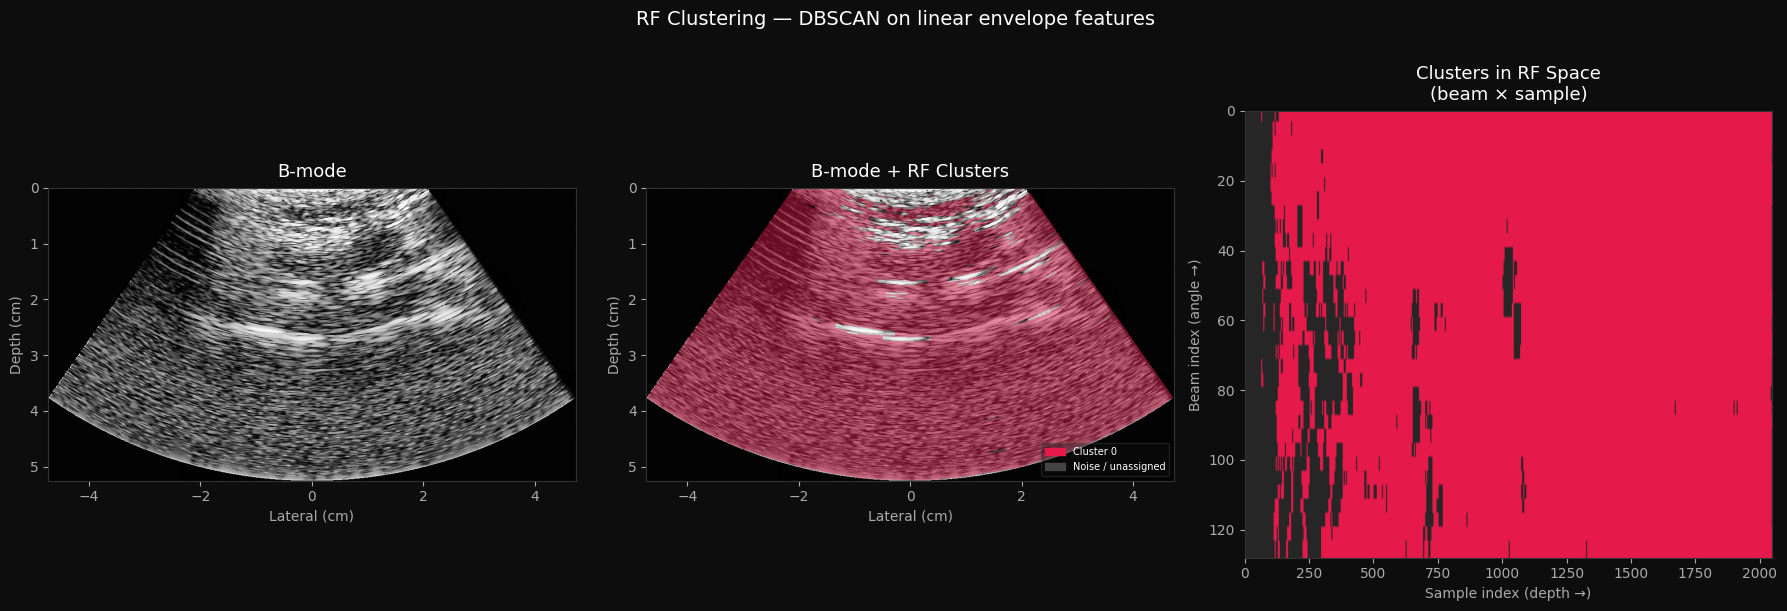


Pixel (300,300)  →  beam 64,  sample 1025
  Cluster label : 0
  Raw envelope  : 57.1301
  Depth         : 2.63 cm
  Angle         : 0.28°


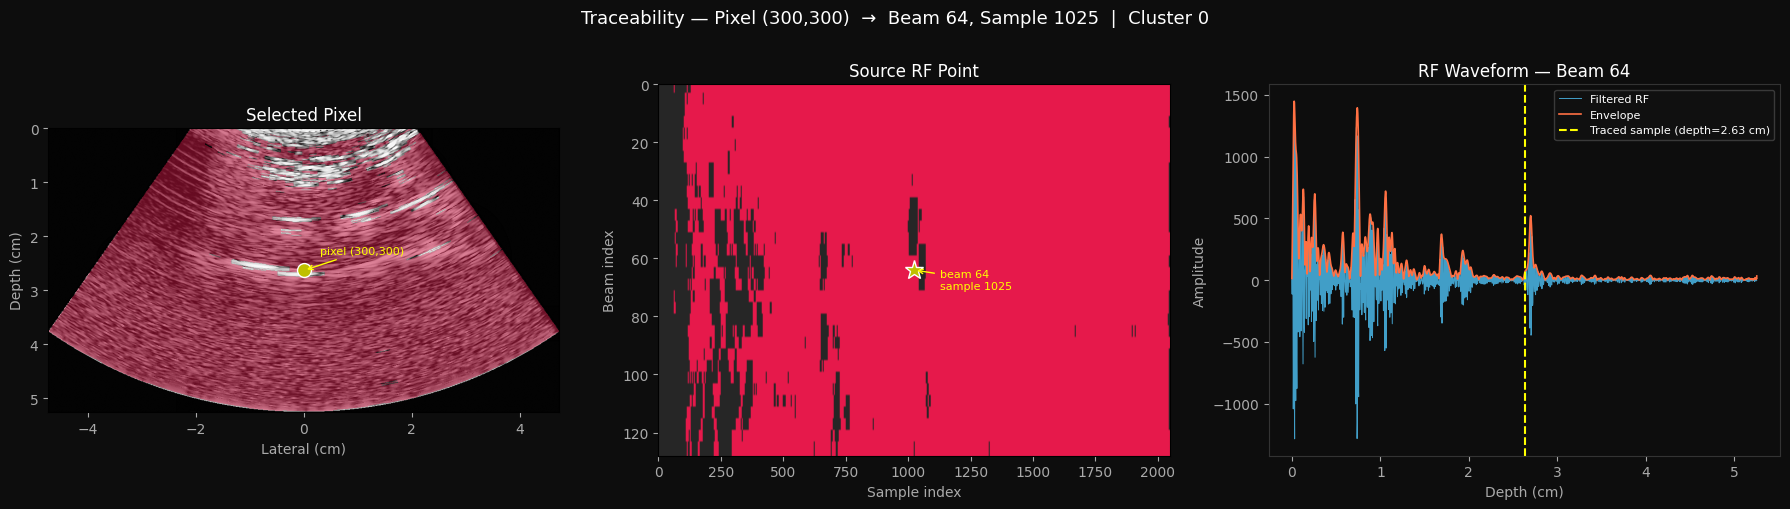

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.signal import hilbert, butter, filtfilt
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import cv2
from settings import (
    center_freq,
    fractional_bw,
    sector_angle_deg,
    curvature_radius_mm,
)


# =============================================================================
# Anisotropic Diffusion
# =============================================================================

def anisotropic_diffusion(img, niter=5, kappa=30, gamma=0.1):
    img = img.astype(np.float32)
    for _ in range(niter):
        nablaN = np.roll(img, -1, axis=0) - img
        nablaS = np.roll(img,  1, axis=0) - img
        nablaE = np.roll(img, -1, axis=1) - img
        nablaW = np.roll(img,  1, axis=1) - img
        cN = np.exp(-(nablaN / kappa) ** 2)
        cS = np.exp(-(nablaS / kappa) ** 2)
        cE = np.exp(-(nablaE / kappa) ** 2)
        cW = np.exp(-(nablaW / kappa) ** 2)
        img += gamma * (cN * nablaN + cS * nablaS + cE * nablaE + cW * nablaW)
    return img


# =============================================================================
# RF CLUSTERING
# =============================================================================

def cluster_rf_data(
    envelope_raw,           # Linear envelope BEFORE normalization, shape (num_beams, num_samples)
    n_features=5,           # Number of local features per RF sample
    downsample_beams=4,     # Spatial downsampling for speed (every Nth beam)
    downsample_samples=4,   # Spatial downsampling for speed (every Nth sample)
    dbscan_eps=0.35,        # DBSCAN neighbourhood radius in feature space
    dbscan_min_samples=20,  # Minimum points to form a core cluster
    window=5,               # Half-window for local feature extraction
):
    """
    Cluster the raw RF envelope in feature space using DBSCAN.

    For each (beam, sample) position we build a local feature vector:
        [mean amplitude, std amplitude, max amplitude, skewness, local gradient]
    computed over a small neighbourhood window.  DBSCAN then groups positions
    that have similar local RF texture — independently of any intensity
    normalisation or log compression.

    Returns
    -------
    cluster_map : ndarray, shape (num_beams, num_samples), dtype int
        Cluster label per RF sample.  -1 = noise / unassigned.
    ds_beams : 1-D index array (downsampled beam indices)
    ds_samples : 1-D index array (downsampled sample indices)
    """
    num_beams, num_samples = envelope_raw.shape

    # --- Downsampled index grids ---
    ds_beams   = np.arange(0, num_beams,   downsample_beams)
    ds_samples = np.arange(0, num_samples, downsample_samples)
    Ib, Is = np.meshgrid(ds_beams, ds_samples, indexing="ij")
    Ib = Ib.ravel()
    Is = Is.ravel()
    n_pts = len(Ib)

    print(f"  Building features for {n_pts} RF points …")

    # --- Build feature matrix ---
    features = np.zeros((n_pts, n_features), dtype=np.float32)

    for idx in range(n_pts):
        ib, is_ = Ib[idx], Is[idx]
        # Local neighbourhood (clipped to array bounds)
        b0, b1 = max(0, ib - window), min(num_beams,   ib + window + 1)
        s0, s1 = max(0, is_ - window), min(num_samples, is_ + window + 1)
        patch = envelope_raw[b0:b1, s0:s1].ravel()

        mean_a = patch.mean()
        std_a  = patch.std()  + 1e-9
        max_a  = patch.max()

        # Skewness (third standardised moment)
        skew = np.mean(((patch - mean_a) / std_a) ** 3)

        # Local axial gradient (along depth axis)
        grad_s0 = max(0, is_ - 1)
        grad_s1 = min(num_samples - 1, is_ + 1)
        grad = (envelope_raw[ib, grad_s1] - envelope_raw[ib, grad_s0]) / (
            (grad_s1 - grad_s0) + 1e-9
        )

        features[idx] = [mean_a, std_a, max_a, skew, grad]

    # --- Standardise features ---
    scaler   = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # --- DBSCAN ---
    print(f"  Running DBSCAN (eps={dbscan_eps}, min_samples={dbscan_min_samples}) …")
    db = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples, n_jobs=-1)
    labels = db.fit_predict(features_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = np.sum(labels == -1)
    print(f"  Found {n_clusters} clusters, {n_noise} noise points ({100*n_noise/n_pts:.1f}%)")

    # --- Expand labels back to full RF grid (nearest-neighbour fill) ---
    cluster_map = np.full((num_beams, num_samples), -1, dtype=int)
    cluster_map[Ib, Is] = labels

    # Simple nearest-neighbour fill for non-sampled positions
    # using the downsampled label at the nearest grid point
    label_grid = labels.reshape(len(ds_beams), len(ds_samples))
    for ib_full in range(num_beams):
        ib_ds = np.argmin(np.abs(ds_beams - ib_full))
        for is_full in range(num_samples):
            is_ds = np.argmin(np.abs(ds_samples - is_full))
            cluster_map[ib_full, is_full] = label_grid[ib_ds, is_ds]

    return cluster_map, ds_beams, ds_samples


# =============================================================================
# PIXEL ↔ RF TRACEABILITY MAP
# =============================================================================

def build_pixel_rf_map(
    theta,          # beam angles, shape (num_beams,)
    depths_m,       # depth per sample, shape (num_samples,)
    Rcurv,          # curvature radius in metres
    output_resolution,
    x_lin,          # cartesian x-axis of output image
    y_lin,          # cartesian y-axis of output image
    sector_angle,
):
    """
    For every pixel (row, col) in the B-mode image return the (beam_index,
    sample_index) of the RF data point it was interpolated from.

    Returns
    -------
    pixel_beam   : ndarray (H, W) int   — beam index (-1 outside sector)
    pixel_sample : ndarray (H, W) int   — sample index (-1 outside sector)
    """
    Xg, Yg = np.meshgrid(x_lin, y_lin)

    # Polar coords of each output pixel
    r_grid     = np.sqrt(Xg ** 2 + (Yg + Rcurv) ** 2)
    theta_grid = np.arctan2(Xg, Yg + Rcurv)
    depth_grid = r_grid - Rcurv

    # Sector mask
    max_depth = depths_m[-1]
    mask = (
        (np.abs(theta_grid) <= sector_angle / 2) &
        (depth_grid >= 0) &
        (depth_grid <= max_depth)
    )

    # Map continuous (theta, depth) → nearest discrete (beam, sample) indices
    pixel_beam   = np.full(output_resolution, -1, dtype=int)
    pixel_sample = np.full(output_resolution, -1, dtype=int)

    th_idx = np.argmin(
        np.abs(theta_grid[:, :, None] - theta[None, None, :]), axis=2
    )
    sa_idx = np.argmin(
        np.abs(depth_grid[:, :, None] - depths_m[None, None, :]), axis=2
    )

    pixel_beam[mask]   = th_idx[mask]
    pixel_sample[mask] = sa_idx[mask]

    return pixel_beam, pixel_sample


# =============================================================================
# MAIN PIPELINE
# =============================================================================

def rf_to_bmode_clustered(
    filepath,
    center_freq=5e6,
    fractional_bw=0.6,
    sector_angle_deg=70,
    curvature_radius_mm=30,
    dynamic_range=60,
    tgc_exponent=1.5,
    output_resolution=(600, 600),
    fs=30e6,
    c=1540,
    # Clustering params
    dbscan_eps=0.35,
    dbscan_min_samples=20,
    downsample_beams=4,
    downsample_samples=4,
    # Interactive tracing
    trace_pixel=None,       # (row, col) pixel to highlight in RF space, or None
):
    """
    Full pipeline: load → filter → envelope → TGC → scan-convert →
    RF clustering → overlay on B-mode → pixel↔RF traceability.

    Parameters
    ----------
    trace_pixel : tuple (row, col) or None
        If given, a fourth figure highlights which RF sample corresponds
        to that pixel, and vice-versa.
    """

    # ------------------------------------------------------------------
    # 1) Load
    # ------------------------------------------------------------------
    data = np.genfromtxt(filepath, delimiter=",", filling_values=0.0)
    if data.ndim == 1:
        data = data[np.newaxis, :]
    if data.shape[1] < data.shape[0]:
        data = data.T

    num_beams, num_samples = data.shape
    print(f"RF data shape: {data.shape}  →  {num_beams} beams × {num_samples} samples")

    # ------------------------------------------------------------------
    # 2) Bandpass filter
    # ------------------------------------------------------------------
    low  = np.clip((center_freq * (1 - fractional_bw / 2)) / (fs / 2), 1e-4, 0.9999)
    high = np.clip((center_freq * (1 + fractional_bw / 2)) / (fs / 2), 1e-4, 0.9999)
    b, a = butter(4, [low, high], btype="band")
    data = filtfilt(b, a, data, axis=1)

    # ------------------------------------------------------------------
    # 3) Envelope detection (pre-normalisation — used for clustering)
    # ------------------------------------------------------------------
    analytic     = hilbert(data, axis=1)
    envelope_raw = np.abs(analytic)      # LINEAR, un-normalised envelope

    # ------------------------------------------------------------------
    # 4) TGC → log compression → normalise
    # ------------------------------------------------------------------
    depths_idx = np.arange(num_samples)
    tgc        = (depths_idx / depths_idx[-1]) ** tgc_exponent + 1.0
    envelope   = envelope_raw * tgc[np.newaxis, :]
    envelope  /= np.max(envelope) + 1e-12

    bmode = 20 * np.log10(envelope + 1e-6)
    bmode = np.clip(bmode, -dynamic_range, 0.0)
    bmode = (bmode + dynamic_range) / dynamic_range
    bmode = gaussian_filter(bmode, sigma=0.5)

    # ------------------------------------------------------------------
    # 5) Scan conversion geometry
    # ------------------------------------------------------------------
    sector_angle = np.deg2rad(sector_angle_deg)
    dr           = c / (2 * fs)
    depths_m     = np.arange(num_samples) * dr
    Rcurv        = curvature_radius_mm / 1000.0
    theta        = np.linspace(-sector_angle / 2, sector_angle / 2, num_beams)

    max_depth = depths_m[-1]
    x_max     = (Rcurv + max_depth) * np.sin(sector_angle / 2)
    x_lin     = np.linspace(-x_max, x_max, output_resolution[1])
    y_lin     = np.linspace(0, max_depth,   output_resolution[0])
    Xg, Yg   = np.meshgrid(x_lin, y_lin)

    r_grid     = np.sqrt(Xg ** 2 + (Yg + Rcurv) ** 2)
    theta_grid = np.arctan2(Xg, Yg + Rcurv)

    interp = RegularGridInterpolator(
        (theta, depths_m), bmode,
        method="linear", bounds_error=False, fill_value=0.0,
    )
    query_pts = np.column_stack((theta_grid.ravel(), r_grid.ravel() - Rcurv))
    cart      = interp(query_pts).reshape(output_resolution)

    # ------------------------------------------------------------------
    # 6) Sector mask
    # ------------------------------------------------------------------
    mask = (
        (np.abs(theta_grid) <= sector_angle / 2) &
        (r_grid >= Rcurv) &
        (r_grid <= Rcurv + max_depth)
    )
    cart_masked = np.where(mask, cart, 0.0)

    # ------------------------------------------------------------------
    # 7) Post-processing filters
    # ------------------------------------------------------------------
    img8            = np.clip(cart_masked * 255, 0, 255).astype(np.uint8)
    img_diff        = anisotropic_diffusion(img8, niter=5, kappa=30, gamma=0.1)
    img_diff_u8     = np.clip(img_diff, 0, 255).astype(np.uint8)
    clahe           = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe       = clahe.apply(img_diff_u8)
    kernel_sharp    = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    img_sharp       = cv2.filter2D(img_clahe, -1, kernel_sharp)
    final_img       = img_sharp.astype(np.float32) / 255.0

    # ------------------------------------------------------------------
    # 8) RF CLUSTERING  (on un-normalised envelope)
    # ------------------------------------------------------------------
    print("\nClustering RF data …")
    cluster_map, ds_beams, ds_samples = cluster_rf_data(
        envelope_raw,
        downsample_beams=downsample_beams,
        downsample_samples=downsample_samples,
        dbscan_eps=dbscan_eps,
        dbscan_min_samples=dbscan_min_samples,
    )

    # ------------------------------------------------------------------
    # 9) PIXEL ↔ RF TRACEABILITY MAP
    # ------------------------------------------------------------------
    print("\nBuilding pixel↔RF map …")
    pixel_beam, pixel_sample = build_pixel_rf_map(
        theta, depths_m, Rcurv,
        output_resolution, x_lin, y_lin, sector_angle,
    )

    # Project cluster label onto each B-mode pixel
    cluster_img = np.full(output_resolution, -1, dtype=int)
    valid = (pixel_beam >= 0)
    cluster_img[valid] = cluster_map[pixel_beam[valid], pixel_sample[valid]]
    cluster_img[~mask] = -1   # outside sector → noise

    # ------------------------------------------------------------------
    # 10) Colour overlay
    # ------------------------------------------------------------------
    unique_labels = sorted(set(cluster_img[mask].ravel()))
    if -1 in unique_labels:
        unique_labels.remove(-1)

    # Build a consistent colour palette (skip black/very-dark colours)
    palette_base = [
        "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
        "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990",
        "#dcbeff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
        "#808000", "#ffd8b1", "#000075", "#a9a9a9",
    ]
    label_to_color = {}
    for i, lbl in enumerate(unique_labels):
        label_to_color[lbl] = palette_base[i % len(palette_base)]

    # RGBA overlay image
    overlay = np.zeros((*output_resolution, 4), dtype=np.float32)
    for lbl, hexcol in label_to_color.items():
        rgb = mcolors.to_rgb(hexcol)
        region = (cluster_img == lbl) & mask
        overlay[region, :3] = rgb
        overlay[region,  3] = 0.45    # alpha — adjust for more/less transparency

    # ------------------------------------------------------------------
    # 11) VISUALISATION
    # ------------------------------------------------------------------
    extent_cm = [
        x_lin[0] * 100, x_lin[-1] * 100,
        y_lin[-1] * 100, y_lin[0] * 100,
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor("#0d0d0d")
    for ax in axes:
        ax.set_facecolor("#0d0d0d")

    # --- Panel 1: plain B-mode ---
    axes[0].imshow(final_img, cmap="gray", origin="upper", extent=extent_cm)
    axes[0].set_title("B-mode", color="white", fontsize=13, pad=8)
    axes[0].set_xlabel("Lateral (cm)", color="#aaaaaa")
    axes[0].set_ylabel("Depth (cm)",   color="#aaaaaa")
    axes[0].tick_params(colors="#aaaaaa")
    for sp in axes[0].spines.values():
        sp.set_edgecolor("#333333")

    # --- Panel 2: B-mode + cluster overlay ---
    axes[1].imshow(final_img, cmap="gray", origin="upper", extent=extent_cm)
    axes[1].imshow(overlay,               origin="upper", extent=extent_cm)
    axes[1].set_title("B-mode + RF Clusters", color="white", fontsize=13, pad=8)
    axes[1].set_xlabel("Lateral (cm)", color="#aaaaaa")
    axes[1].set_ylabel("Depth (cm)",   color="#aaaaaa")
    axes[1].tick_params(colors="#aaaaaa")
    for sp in axes[1].spines.values():
        sp.set_edgecolor("#333333")

    # Cluster legend
    legend_patches = [
        mpatches.Patch(color=col, label=f"Cluster {lbl}")
        for lbl, col in label_to_color.items()
    ]
    legend_patches.append(mpatches.Patch(color="#444444", label="Noise / unassigned"))
    axes[1].legend(
        handles=legend_patches, loc="lower right",
        fontsize=7, framealpha=0.4,
        facecolor="#111111", edgecolor="#444444",
        labelcolor="white",
    )

    # --- Panel 3: cluster map in RF space ---
    rf_cluster_display = np.zeros((*cluster_map.shape, 3), dtype=np.float32)
    for lbl, hexcol in label_to_color.items():
        rf_cluster_display[cluster_map == lbl] = mcolors.to_rgb(hexcol)
    rf_cluster_display[cluster_map == -1] = [0.15, 0.15, 0.15]

    ax3 = axes[2]
    ax3.imshow(
        rf_cluster_display, origin="upper", aspect="auto",
        extent=[0, num_samples, num_beams, 0],
    )
    ax3.set_title("Clusters in RF Space\n(beam × sample)", color="white", fontsize=13, pad=8)
    ax3.set_xlabel("Sample index (depth →)", color="#aaaaaa")
    ax3.set_ylabel("Beam index (angle →)",   color="#aaaaaa")
    ax3.tick_params(colors="#aaaaaa")
    for sp in ax3.spines.values():
        sp.set_edgecolor("#333333")

    plt.suptitle("RF Clustering — DBSCAN on linear envelope features",
                 color="white", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("bmode_clustered.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()

    # ------------------------------------------------------------------
    # 12) PIXEL TRACEABILITY  (optional fourth figure)
    # ------------------------------------------------------------------
    if trace_pixel is not None:
        row, col = trace_pixel
        b_idx = pixel_beam[row, col]
        s_idx = pixel_sample[row, col]

        if b_idx < 0:
            print(f"Pixel ({row},{col}) is outside the sector — no RF reference.")
        else:
            print(f"\nPixel ({row},{col})  →  beam {b_idx},  sample {s_idx}")
            print(f"  Cluster label : {cluster_map[b_idx, s_idx]}")
            print(f"  Raw envelope  : {envelope_raw[b_idx, s_idx]:.4f}")
            print(f"  Depth         : {depths_m[s_idx]*100:.2f} cm")
            print(f"  Angle         : {np.rad2deg(theta[b_idx]):.2f}°")

            fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
            fig2.patch.set_facecolor("#0d0d0d")
            for ax in axes2:
                ax.set_facecolor("#0d0d0d")

            # Left: B-mode with the traced pixel marked
            axes2[0].imshow(final_img, cmap="gray", origin="upper", extent=extent_cm)
            axes2[0].imshow(overlay,               origin="upper", extent=extent_cm)
            px_cm = x_lin[col] * 100
            py_cm = y_lin[row] * 100
            axes2[0].plot(px_cm, py_cm, "yo", markersize=10, markeredgecolor="white", lw=1.5)
            axes2[0].annotate(
                f"pixel ({row},{col})",
                xy=(px_cm, py_cm), xytext=(px_cm + 0.3, py_cm - 0.3),
                color="yellow", fontsize=8,
                arrowprops=dict(arrowstyle="->", color="yellow"),
            )
            axes2[0].set_title("Selected Pixel", color="white", fontsize=12)
            axes2[0].set_xlabel("Lateral (cm)", color="#aaaaaa")
            axes2[0].set_ylabel("Depth (cm)",   color="#aaaaaa")
            axes2[0].tick_params(colors="#aaaaaa")

            # Middle: RF cluster map with the source RF point marked
            axes2[1].imshow(rf_cluster_display, origin="upper", aspect="auto",
                            extent=[0, num_samples, num_beams, 0])
            axes2[1].plot(s_idx, b_idx, "y*", markersize=14, markeredgecolor="white")
            axes2[1].annotate(
                f"beam {b_idx}\nsample {s_idx}",
                xy=(s_idx, b_idx), xytext=(s_idx + num_samples * 0.05, b_idx + num_beams * 0.05),
                color="yellow", fontsize=8,
                arrowprops=dict(arrowstyle="->", color="yellow"),
            )
            axes2[1].set_title("Source RF Point", color="white", fontsize=12)
            axes2[1].set_xlabel("Sample index", color="#aaaaaa")
            axes2[1].set_ylabel("Beam index",   color="#aaaaaa")
            axes2[1].tick_params(colors="#aaaaaa")

            # Right: raw RF waveform for that beam
            axes2[2].plot(
                depths_m * 100,
                data[b_idx],
                color="#4fc3f7", linewidth=0.7, alpha=0.8, label="Filtered RF"
            )
            axes2[2].plot(
                depths_m * 100,
                envelope_raw[b_idx],
                color="#ff7043", linewidth=1.2, label="Envelope"
            )
            axes2[2].axvline(
                depths_m[s_idx] * 100,
                color="yellow", linewidth=1.5, linestyle="--",
                label=f"Traced sample (depth={depths_m[s_idx]*100:.2f} cm)"
            )
            axes2[2].set_title(f"RF Waveform — Beam {b_idx}", color="white", fontsize=12)
            axes2[2].set_xlabel("Depth (cm)", color="#aaaaaa")
            axes2[2].set_ylabel("Amplitude",  color="#aaaaaa")
            axes2[2].tick_params(colors="#aaaaaa")
            axes2[2].legend(fontsize=8, facecolor="#111111",
                            edgecolor="#444444", labelcolor="white")
            for sp in axes2[2].spines.values():
                sp.set_edgecolor("#333333")

            plt.suptitle(
                f"Traceability — Pixel ({row},{col})  →  Beam {b_idx}, Sample {s_idx}  |  "
                f"Cluster {cluster_map[b_idx, s_idx]}",
                color="white", fontsize=13, y=1.01,
            )
            plt.tight_layout()
            plt.savefig("bmode_trace.png", dpi=150, bbox_inches="tight",
                        facecolor=fig2.get_facecolor())
            plt.show()

    return {
        "final_img":    final_img,
        "cluster_img":  cluster_img,       # cluster label per B-mode pixel
        "cluster_map":  cluster_map,       # cluster label per RF (beam, sample)
        "pixel_beam":   pixel_beam,        # which beam feeds each B-mode pixel
        "pixel_sample": pixel_sample,      # which sample feeds each B-mode pixel
        "theta":        theta,
        "depths_m":     depths_m,
        "x_lin":        x_lin,
        "y_lin":        y_lin,
        "envelope_raw": envelope_raw,
    }


# =============================================================================
# RUN
# =============================================================================
results = rf_to_bmode_clustered(
    "ae2RF.txt",
    center_freq        = center_freq,       # <-- SET to your probe center frequency
    fractional_bw      = fractional_bw,
    sector_angle_deg   = sector_angle_deg,
    curvature_radius_mm= curvature_radius_mm,
    dynamic_range      = 60,
    output_resolution  = (600, 600),

    # --- Clustering tuning ---
    # Increase eps  → fewer, larger clusters
    # Decrease eps  → more, tighter clusters
    # Increase min_samples → noisier but stricter cluster cores
    dbscan_eps         = 0.35,
    dbscan_min_samples = 20,
    downsample_beams   = 4,    # reduce to 1 for full resolution (slower)
    downsample_samples = 4,

    # --- Traceability ---
    # Set to any (row, col) pixel to trace it back to its RF source.
    # E.g. trace_pixel=(300, 300) traces the centre pixel.
    trace_pixel        = (300, 300),
)

# ------------------------------------------------------------------
# You can also query any pixel interactively after the run:
# ------------------------------------------------------------------
def query_pixel(results, row, col):
    """
    Print the RF origin and cluster for any B-mode pixel after the main run.
    """
    b = results["pixel_beam"][row, col]
    s = results["pixel_sample"][row, col]
    if b < 0:
        print(f"Pixel ({row},{col}) is outside the sector.")
        return
    depth_cm = results["depths_m"][s] * 100
    angle_deg = np.rad2deg(results["theta"][b])
    cluster   = results["cluster_map"][b, s]
    amp       = results["envelope_raw"][b, s]
    print(f"Pixel ({row},{col})")
    print(f"  → Beam   : {b}  (angle {angle_deg:.2f}°)")
    print(f"  → Sample : {s}  (depth {depth_cm:.2f} cm)")
    print(f"  → Cluster: {cluster}")
    print(f"  → Raw envelope amplitude: {amp:.5f}")

# Example: query_pixel(results, 200, 400)